<img src='https://data.actris.eu/static/img/actris-dc-logo.png' width=400 align=right>

# Combining datasets - Elemental and Organic Carbon at Birkenes

In [27]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import json
import requests
import os
import time

## Loading data

This notebook continues from the *Search with ACTRIS Data Portal* example. It reads the `basket.json` file saved there, which contains metadata and access URLs for a set of elemental carbon (EC) and organic carbon (OC) datasets from Birkenes, Norway.

The data can be accessed in two ways — set `protocol` in the cell below:
- **`opendap`** — streams data directly from the THREDDS server (no local files needed)
- **`http`** — downloads the NetCDF files to a local folder

In [28]:
protocol = 'opendap' # choose 'http' or 'opendap'

In [29]:
# Navigate to the Search and access folder where basket.json is stored
folder = os.getcwd().replace("  Analyse ACTRIS data", "   Search and access")
os.chdir(folder)

In [30]:
with open('static/basket.json') as f:
    md = json.load(f)

if protocol == 'http':
    os.makedirs("static/data_oc_ec", exist_ok=True)
    for entry in md.values():
        r = requests.get(entry['downloadUrl'])
        filename = r.url[-12:]
        with open(os.path.join("static/data_oc_ec", filename), mode="wb") as file:
            file.write(r.content)
    print(f"Downloaded {len(md)} files to static/data_oc_ec/")

## Data processing

The ACTRIS In-Situ NetCDF files follow a standard naming convention where measurement variables start with `v_`. Each file may contain multiple carbon fractions (EC, OC, total carbon) and size fractions (PM10, PM2.5). Here we extract the PM10 arithmetic mean for each carbon type.

Documentation for the In-Situ NetCDF file format: https://ebas.pages.nilu.no/ebas-io/fileformat_netcdf/index.html

In [31]:
ds_elemental_carbon = []
ds_organic_carbon = []
ds_total_carbon = []

EXCLUDE = ('_uncertainty', '_d_Fraction', '_max_', '_pm25', '_corrected')

def pick_best(candidates, ds):
    for suffix in ('_pm10_amean', '_pm10', '_amean', ''):
        match = [v for v in candidates if v.endswith(suffix)]
        if match:
            return ds[match[0]]

def load_entry(entry):
    # Skip datasets that require authentication
    if requests.head(entry['downloadUrl'], timeout=10).status_code != 200:
        return entry, None
    url = entry['opendapUrl'] if protocol == 'opendap' else 'static/data_oc_ec/{}'.format(entry['downloadUrl'][-12:])
    for attempt in range(3):
        try:
            return entry, xr.open_dataset(url)
        except Exception:
            time.sleep(3) if attempt < 2 else None
    return entry, None

for entry in md.values():
    _, ds = load_entry(entry)
    if ds is None:
        continue
    candidates = [v for v in ds.data_vars if v.startswith('v_') and not any(x in v for x in EXCLUDE)]
    ec = pick_best([v for v in candidates if 'elemental_carbon' in v], ds)
    oc = pick_best([v for v in candidates if 'organic_carbon' in v], ds)
    tc = pick_best([v for v in candidates if 'total_carbon' in v], ds)
    if ec is not None: ds_elemental_carbon.append(ec)
    if oc is not None: ds_organic_carbon.append(oc)
    if tc is not None: ds_total_carbon.append(tc)

print(f"Loaded: {len(ds_elemental_carbon)} EC, {len(ds_organic_carbon)} OC, {len(ds_total_carbon)} TC time series")

Loaded: 14 EC, 16 OC, 16 TC time series


In [32]:
# Sort each list chronologically before concatenating
sort_key = lambda x: x.time.values[0] if len(x.time) > 0 else np.datetime64('NaT')
ds_elemental_carbon.sort(key=sort_key)
ds_organic_carbon.sort(key=sort_key)
ds_total_carbon.sort(key=sort_key)

In [33]:
def concat_with_gaps(arrays):
    """Concatenate DataArrays with a NaN gap between segments so matplotlib
    does not draw connecting lines across time gaps between files."""
    pieces = []
    for i, da in enumerate(arrays):
        pieces.append(da)
        if i < len(arrays) - 1:
            gap_time = da.time.values[-1] + (arrays[i+1].time.values[0] - da.time.values[-1]) / 2
            pieces.append(xr.DataArray([np.nan], dims=['time'],
                                       coords={'time': [gap_time]}, attrs=da.attrs))
    return xr.concat(pieces, dim='time')

ec_ds = concat_with_gaps(ds_elemental_carbon)
oc_ds = concat_with_gaps(ds_organic_carbon)
tc_ds = concat_with_gaps(ds_total_carbon)

## Data visualisation

The plot below shows the full time series of PM10 elemental carbon (EC) and organic carbon (OC) at Birkenes, combining all available annual files into a single continuous record. OC is consistently higher than EC, with both showing clear seasonal variability and episodic peaks associated with long-range transport events.

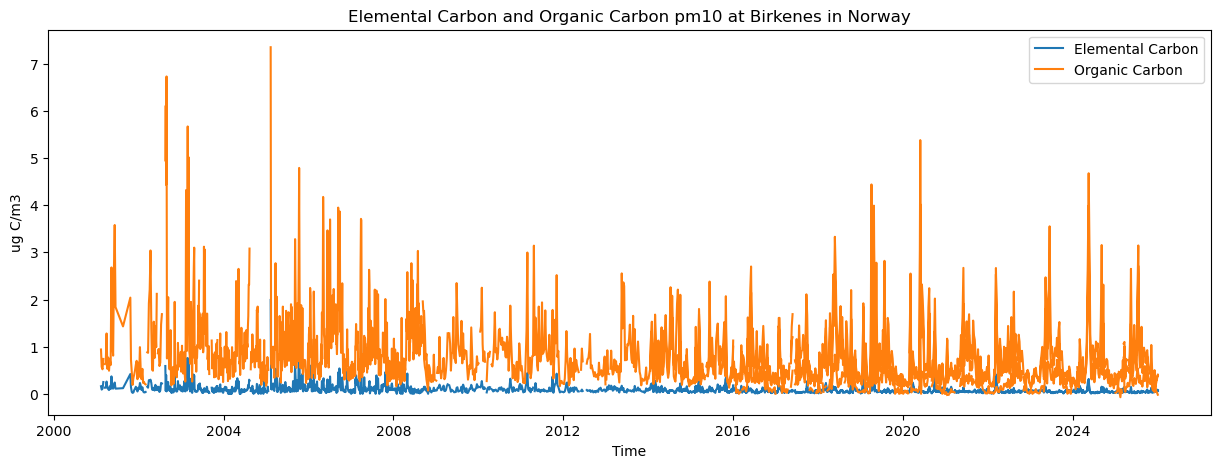

In [34]:
plt.figure(figsize=(15, 5))
plt.plot(ec_ds.time, ec_ds, label='Elemental Carbon')
plt.plot(oc_ds.time, oc_ds, label='Organic Carbon')
#plt.plot(tc_ds.time, tc_ds, label='Total Carbon')
plt.legend()
plt.ylabel('ug C/m3')
plt.xlabel('Time')
plt.title('Elemental Carbon and Organic Carbon pm10 at Birkenes in Norway')
plt.show()

The same approach can be applied to any variable or station available through the [ACTRIS Data Portal](https://data.actris.eu). To also show total carbon, uncomment the `tc_ds` line in the plot cell. The OC/EC ratio can be computed as `oc_ds / ec_ds` and is commonly used as an indicator of secondary organic aerosol formation.